# Prac 05

In this homework you are going to implement the **Floyd-Steinberg dithering** algorithm. Dithering, in general, means that we are adding noise to the signal (in our case digital image) in order to perceive it better. In other words, by adding the noise the objective quality will be worse but the subjective quality will be better (i.e. the image will "look" better).

The details of FS dithering can be found in this [wiki](https://en.wikipedia.org/wiki/Floyd%E2%80%93Steinberg_dithering) page. In order to implement the dithering, we will implement the following steps:
* Define colour pallette
* Quantize the image to obtain the baseline and compute the average quantization error
* Implement FS dithering and compute the average quantization error

You will also have to answer the question at the end of this notebook.

Note: In this homework, you will have the chance to earn some extra points. See the "Bonus" section at the end of the notebook. Good luck!

As always, you are encouraged to use your own images :-)

In [2]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

Let's load the image.

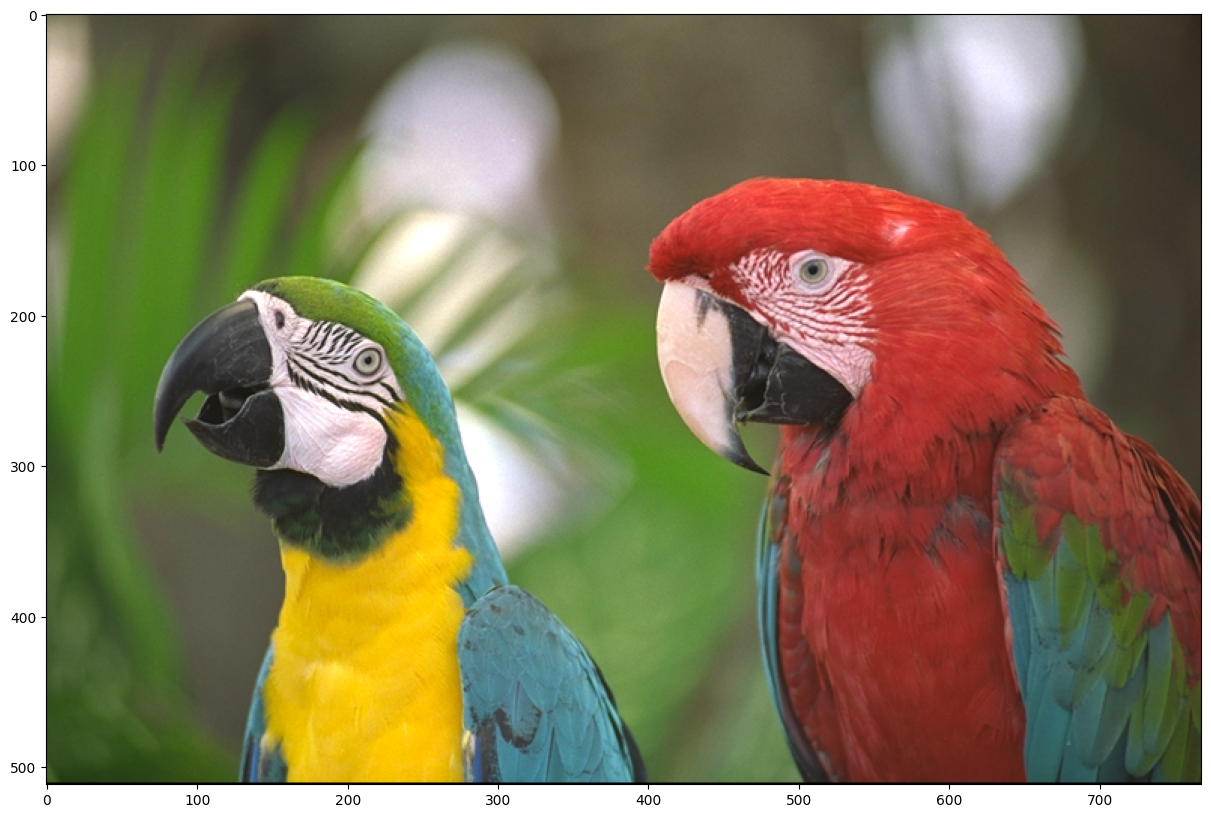

In [3]:
# Load image
img = cv2.imread('data/kodim23.png')
# Convert it to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Plot it
plt.imshow(img)

Let's start with gray tones first.

In [6]:
# Black, dark gray, light gray, white
colors = np.array([[0, 0, 0],
                   [64, 64, 64],
                   [192, 192, 192],
                   [255, 255, 255]])

Using the colour pallette, let's quantize the original image.

In [7]:
img.shape

(512, 768, 3)

In [ ]:
np.sqrt(np.sum((np.array(list(img[0, 0, :]), dtype=np.float16) - img)**2))  

In [8]:
np.arange(img.size)

array([      0,       1,       2, ..., 1179645, 1179646, 1179647],
      shape=(1179648,))

In [10]:
# Cast the image to float
img = img.astype(np.float16)

# Prepare for quantization
rows, cols, channels = img.shape
quantized = np.zeros_like(img)

# Apply quantization
for r in range(rows):
    for c in range(cols):
        # Extract the original pixel value
        pixel = img[r, c, :].copy()

        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        # Note: You may need more than one line of code here
        distances = np.sum((pixel - colors)**2, axis=1)
        new_pixel = colors[np.argmin(distances)]
        # Apply quantization
        quantized[r, c, :] = new_pixel

In [24]:
quantized = np.clip(quantized, 0, 255).astype(np.uint8)

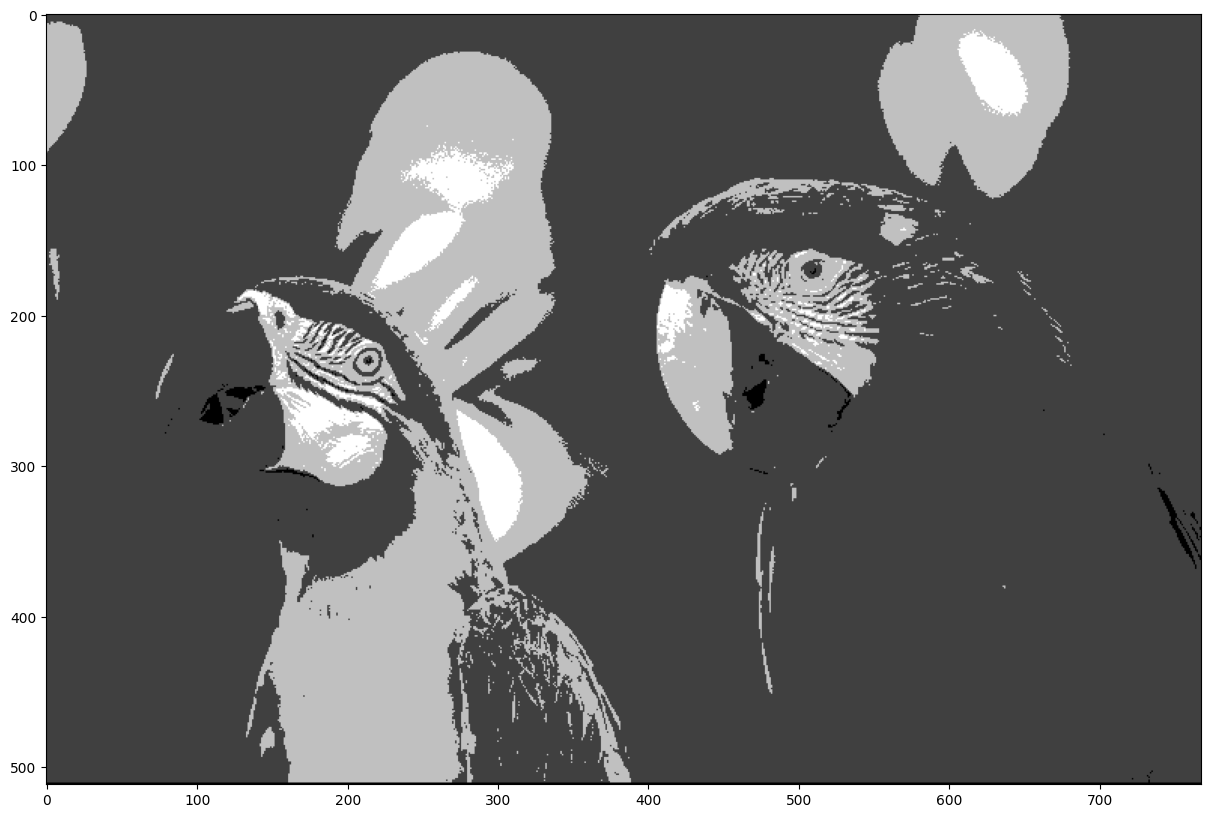

In [12]:
# Show quantized image (don't forget to cast back to uint8)
plt.imshow(quantized.astype(np.uint8), cmap="gray")

In [25]:
quantized.shape

(512, 768, 3)

In [15]:
# Compute average quantization error
avg_quant_error = np.mean(np.square(img - quantized))

In [16]:
avg_quant_error

np.float16(2.14e+03)

#### Floyd-Steinberg Dithering
We are now going to implement the FS dithering and compare it to the optimally quantized image we have calculated above.

In [17]:
# Make a temporal copy of the original image, we will need it for error diffusion
img_tmp = np.copy(img)
dithering = np.zeros_like(img)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the original pixel value
        pixel = img_tmp[r, c, :]
        # Find the closest colour from the pallette (using absolute value/Euclidean distance)
        # Note: You may need more than one line of code here
        distances = np.sum((pixel - colors)**2, axis=1)
        new_pixel = colors[np.argmin(distances)]

        # Compute quantization error
        quant_error = pixel - new_pixel

        # Diffuse the quantization error accroding to the FS diffusion matrix
        # Note: You may need more than one line of code here
        img_tmp[r, c + 1, :] += quant_error * 7/16
        img_tmp[r + 1, c + 1, :] += quant_error * 1/16
        img_tmp[r + 1, c, :] += quant_error * 5/16
        img_tmp[r + 1, c - 1, :] += quant_error * 3/16

        # Apply dithering
        dithering[r, c, :] = new_pixel

In [21]:
dithering = np.clip(dithering, 0, 255).astype(np.uint8)

(<Axes: >, <matplotlib.image.AxesImage at 0x22a963a8b90>)

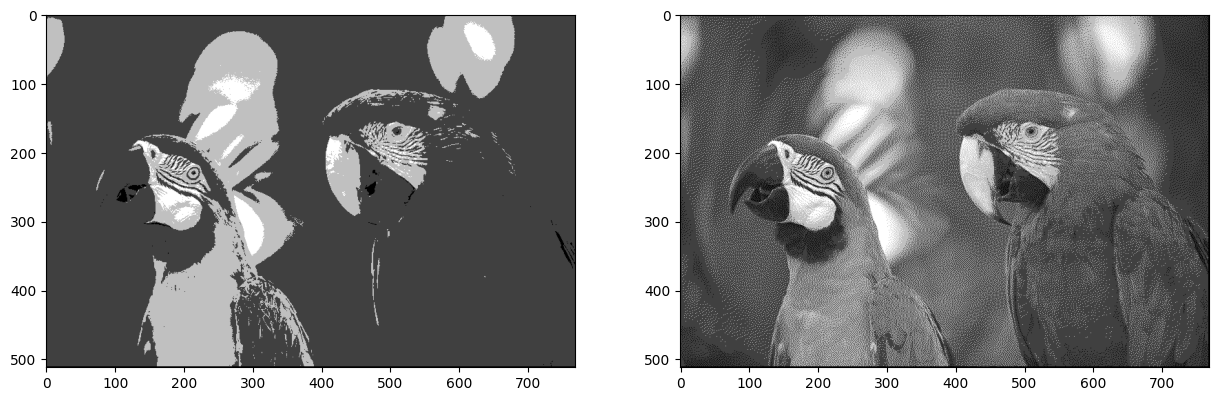

In [ ]:
# Show quantized image (don't forget to cast back to uint8)
plt.subplot(121), plt.imshow(quantized.astype(np.uint8))   # optimally quantized
plt.subplot(122), plt.imshow(dithering)   # dithering

In [19]:
# Compute average quantization error for dithered image
avg_dith_error = np.mean(np.square(img - dithering.astype(np.uint8)))

In [20]:
avg_dith_error

np.float16(3.302e+03)

### Questions
* Which image has higher quantization error? Optimally quantized or dithered?

A: FS dithered image because it frequently chooses colors that are further away from the original pixel to compensate for errors elsewhere.

* Which image looks better to you?

A: FS dithered

* Can you repeat the same process using only two colours: black and white? Show me :-)

A: change color pallette to contain only two colors: [(0, 0, 0), (255, 255, 255)], remain procedure the same: 

In [31]:
img.shape

(512, 768, 3)

(<Axes: >, <matplotlib.image.AxesImage at 0x1c412202490>)

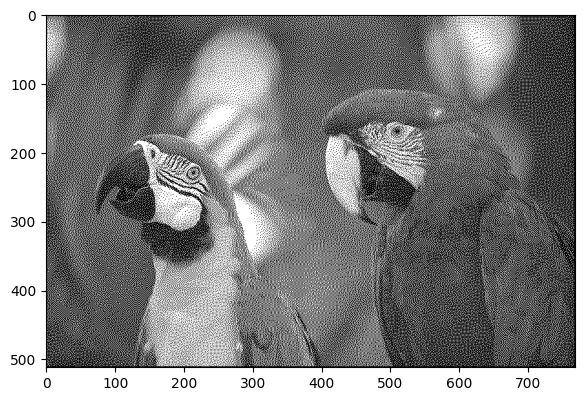

In [16]:
colors_bw = np.array([[0, 0, 0],
                   [255, 255, 255]])

rows, cols, channels = img.shape
img_tmp = cv2.cvtColor(img.astype(np.float32), cv2.COLOR_RGB2GRAY)
img_tmp = img_tmp.astype(np.float16)
dithering_bw = np.zeros_like(img_tmp, dtype=np.uint8)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        # Extract the original pixel value
        pixel = img_tmp[r, c]
        new_pixel = 255 if pixel > 127.5 else 0

        # Compute quantization error
        quant_error = pixel - new_pixel

        # Diffuse the quantization error accroding to the FS diffusion matrix
        # Note: You may need more than one line of code here
        img_tmp[r, c + 1] += quant_error * 7/16
        img_tmp[r + 1, c + 1] += quant_error * 1/16
        img_tmp[r + 1, c] += quant_error * 5/16
        img_tmp[r + 1, c - 1] += quant_error * 3/16

        # Apply dithering
        dithering_bw[r, c] = new_pixel

dithering_bw = np.clip(dithering_bw, 0, 255).astype(np.uint8)

plt.subplot(122), plt.imshow(dithering_bw, cmap="gray") 

### Bonus Points

Repeat the homework using a diffrerent image pallette. For instance, you can use an optimal colour
pallette that we can calculate via k-means algorithm. The following snippet of code will give you the 16
optimal colours for your original image.

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=16).fit(
    np.reshape(img, (-1, 1))
    # img
    )
colors = kmeans.cluster_centers_
colors = colors.astype(np.uint8)
colors


In [40]:
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)[:, :, None]
gray_img.shape


(512, 768, 1)

(<Axes: >, <matplotlib.image.AxesImage at 0x1c41241a350>)

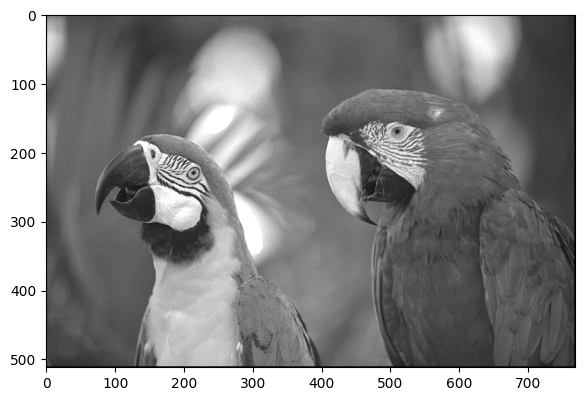

In [41]:
dithering_bw = np.zeros_like(gray_img, dtype=np.uint8)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        pixel = gray_img[r, c, :]
        
        distances = np.sum((pixel - colors)**2, axis=1)
        new_pixel = colors[np.argmin(distances)]

        # Compute quantization error
        quant_error = (pixel - new_pixel)

        # Diffuse the quantization error accroding to the FS diffusion matrix
        # Note: You may need more than one line of code here
        gray_img[r, c + 1, :] += quant_error * 7/16
        gray_img[r + 1, c + 1, :] += quant_error * 1/16
        gray_img[r + 1, c, :] += quant_error * 5/16
        gray_img[r + 1, c - 1, :] += quant_error * 3/16

        # Apply dithering
        dithering_bw[r, c] = new_pixel

dithering_bw = np.clip(dithering_bw, 0, 255).astype(np.uint8)

plt.subplot(122), plt.imshow(dithering_bw, cmap="gray") 


In [27]:
new_pixel

array([105], dtype=uint8)

Apply FS dithering the same way you did before.

* How does the result look like to you?

A: It looks much smooth, features are more accurate

The result shows a significant improvement in perceived tonal depth. the "staircase" effect (banding) seen in naive quantization is replaced by a high-frequency grain. This grain mimics smooth gradients, making features like shadows and textures look more natural and accurate to the original image.

* What happens if we use 32 colours?

A: Visually it looks the same. While the image quality is technically higher, the visual difference is minimal due to the limited sensitivity of human vision at high frequencies

* And what happens if we use 256 colours?

A: Visually it looks the same as applying 16 color palette but the implementation runs a bit longer 

### 32 color palette

(<Axes: >, <matplotlib.image.AxesImage at 0x1c412670690>)

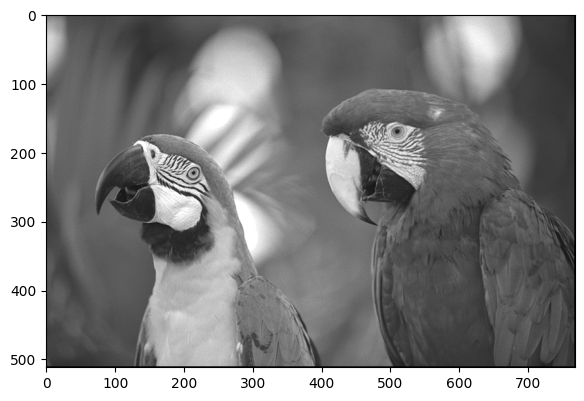

In [42]:
kmeans = KMeans(n_clusters=32).fit(
    np.reshape(img, (-1, 1))
    # img
    )
colors = kmeans.cluster_centers_
colors = colors.astype(np.uint8)

gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)[:, :, None]

dithering_bw = np.zeros_like(gray_img, dtype=np.uint8)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        pixel = gray_img[r, c, :]
        
        distances = np.sum((pixel - colors)**2, axis=1)
        new_pixel = colors[np.argmin(distances)]

        # Compute quantization error
        quant_error = (pixel - new_pixel)

        # Diffuse the quantization error accroding to the FS diffusion matrix
        # Note: You may need more than one line of code here
        gray_img[r, c + 1, :] += quant_error * 7/16
        gray_img[r + 1, c + 1, :] += quant_error * 1/16
        gray_img[r + 1, c, :] += quant_error * 5/16
        gray_img[r + 1, c - 1, :] += quant_error * 3/16

        # Apply dithering
        dithering_bw[r, c] = new_pixel

dithering_bw = np.clip(dithering_bw, 0, 255).astype(np.uint8)

plt.subplot(122), plt.imshow(dithering_bw, cmap="gray") 


### 256 colors palette

(<Axes: >, <matplotlib.image.AxesImage at 0x1c4126c2990>)

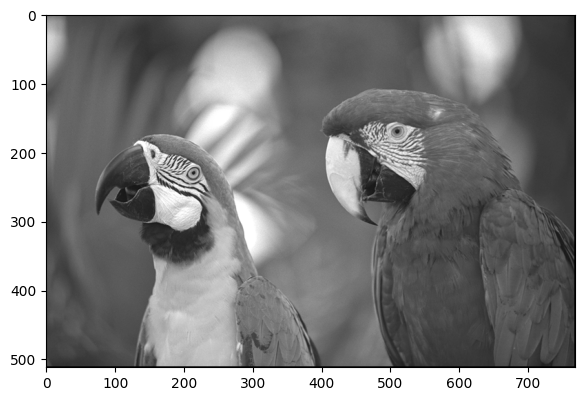

In [43]:
kmeans = KMeans(n_clusters=256).fit(
    np.reshape(img, (-1, 1))
    # img
    )
colors = kmeans.cluster_centers_
colors = colors.astype(np.uint8)

gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32)[:, :, None]

dithering_bw = np.zeros_like(gray_img, dtype=np.uint8)

for r in range(1, rows-1):
    for c in range(1, cols-1):
        pixel = gray_img[r, c, :]
        
        distances = np.sum((pixel - colors)**2, axis=1)
        new_pixel = colors[np.argmin(distances)]

        # Compute quantization error
        quant_error = (pixel - new_pixel)

        # Diffuse the quantization error accroding to the FS diffusion matrix
        # Note: You may need more than one line of code here
        gray_img[r, c + 1, :] += quant_error * 7/16
        gray_img[r + 1, c + 1, :] += quant_error * 1/16
        gray_img[r + 1, c, :] += quant_error * 5/16
        gray_img[r + 1, c - 1, :] += quant_error * 3/16

        # Apply dithering
        dithering_bw[r, c] = new_pixel

dithering_bw = np.clip(dithering_bw, 0, 255).astype(np.uint8)

plt.subplot(122), plt.imshow(dithering_bw, cmap="gray") 
